In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Read the data (column 5 are labels)

In [ ]:
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',names=True,usecols=(0,1,2,3,4,6),dtype=float,comments='#')
names = data.dtype.names
names

('u', 'g', 'r', 'i', 'z', 'z1')

In [4]:
#data without header and labels
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=(0,1,2,3,4,6),dtype=float)

In [6]:
#column 5 are labels
lab=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=5,dtype=str)
lab

array(['QSO', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'GALAXY', 'GALAXY'],
      dtype='<U6')

Build the colors

In [78]:
d = dict(zip(names, data.T))  #create a dictionary 

for diff in ['ug', 'gr', 'ri', 'iz']:
    d[diff]=d[diff[0]]-d[diff[1]] 
d['lab']=lab
d.keys()

X=np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T              #array of color 
labels = np.where(lab == "QSO", 0, 1)                        #0 for quasar, 1 for galaxy
print(labels)

[0 1 1 ... 1 1 1]


In [79]:
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier


In [85]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, labels, test_size=0.33, random_state=67)
X_train.shape

(33500, 4)

### Naive Bayes and Quadratic Discriminant Analysis

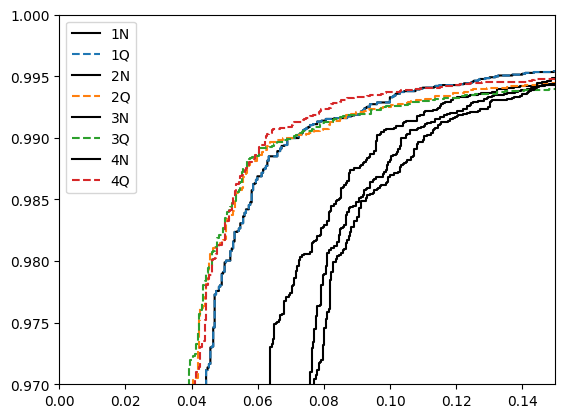

In [93]:
clf1 = GaussianNB()                  #classifier
clf2 = QuadraticDiscriminantAnalysis()


for i in range(4):                          #adding more and more faetures 

    clf1.fit(X_train[:,0:i+1] ,y_train)
    clf2.fit(X_train[:,0:i+1] ,y_train)

    y_prob1 = clf1.predict_proba(X_test[:,0:i+1])  [:,1]          #probability of belonging to the second class
    y_prob2 = clf2.predict_proba(X_test[:,0:i+1])  [:,1]

    fpr1, tpr1, thresh1 = roc_curve(y_test, y_prob1)            #false positive rate, true positive rate, thresholds
    fpr2, tpr2, thresh2 = roc_curve(y_test, y_prob2)
    plt.plot(fpr1, tpr1, label=str(i+1)+"N", c='black')  #plotting ROC curve
    plt.plot(fpr2, tpr2, label=str(i+1)+"Q", linestyle='--')

plt.xlim(0,0.15)
plt.ylim(0.97,1)
plt.legend();

Naive bayes seems to work better with only one feature (maybe it is because they are not independent!).


Insted we notice that for QDA the performance is better with more features and with 4 feature it performs better. 

### GMM Bayes

(0.9, 1.0)

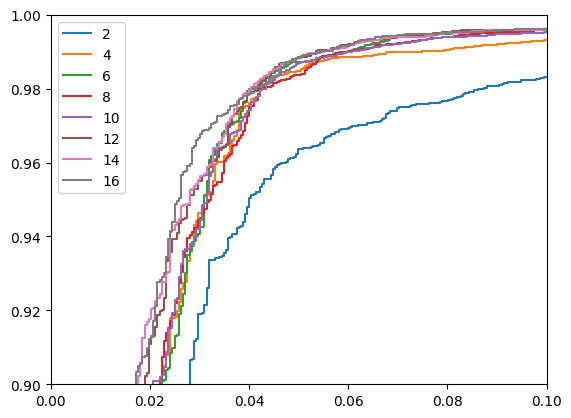

In [96]:
for n in np.arange(2,18)[::2]:                  #incresing the number of gaussians 
    
    clf = GMMBayes(n_components=n)
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

### K Neighbors

(0.96, 1.0)

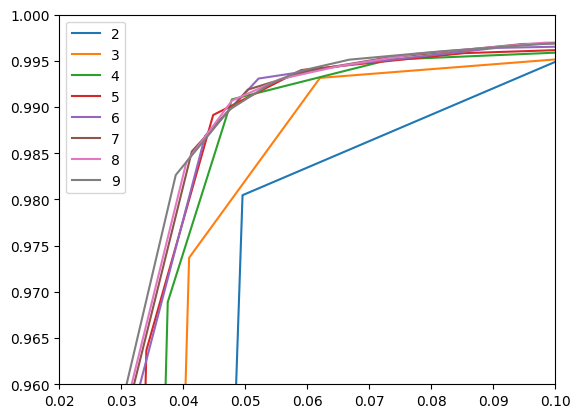

In [99]:
for n in np.arange(2,10):
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()
plt.xlim(0.02,0.1)
plt.ylim(0.96,1)

#### Actually Classify with GMM Bayes, with n=16 components

In [ ]:
clf = GMMBayes(n_components=16)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)


Accuracy:  0.9850909090909091


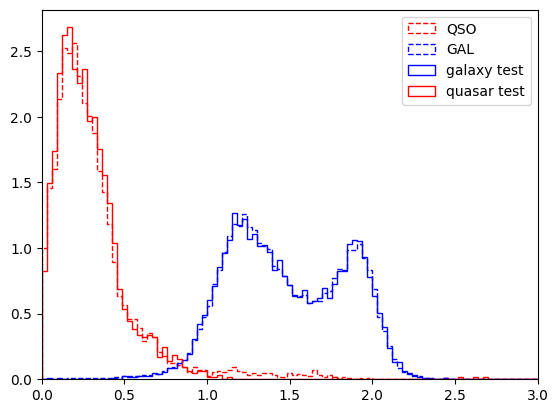

In [112]:
d_test = dict(zip(names, X_test.T))  #create a dictionary for test data

plt.hist(d['ug'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100), color='red', label='QSO', density=True, linestyle='--')
plt.hist(d['ug'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100), color='blue', linestyle='--', label='GAL', density= True)    
plt.hist(X_test[:,0][y_pred==1],histtype='step',bins=np.linspace(0,3,100), label='galaxy test', density=True, color='blue')
plt.hist(X_test[:,0][y_pred==0],histtype='step',bins=np.linspace(0,3,100), label='quasar test', density=True, color='red')
plt.legend()
plt.xlim(0,3);


It is possible to see some contamination of quasar in galaxies

In [119]:
from astroML.utils import completeness_contamination

print("Accuracy: ", np.mean(y_pred==y_test))  #accuracy of the model
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

print("size of the sample (of the test): ", len(y_test))
print("the number of false quasars: ", np.sum((y_pred==0) & (y_test==1))) #when the prediction was of a quasar but the true label was galaxy
print("false quasars rate", np.sum((y_pred==0) & (y_test==1)) / len(y_test))  #rate of false quasars in the sample

Accuracy:  0.9850909090909091
completeness 0.9931588969602934
contamination 0.010470100484857003
size of the sample (of the test):  16500
the number of false quasars:  97
false quasars rate 0.005878787878787879
